In [1]:
import pandas as pd
from pathlib import Path
from sqlite3 import Connection, connect
import matplotlib.pyplot as plt
import numpy as np
import pyref
from pyref.nexafs import load_nexafs, normalize_by_group

import scienceplots
plt.style.use(["science", "no-latex"])

def set_plotting_defaults():
    """
    Set matplotlib rcParams for fontsize and grid defaults.

    This function configures:
    - Font sizes for labels, ticks, legend, and titles
    - Grid appearance (alpha, linestyle, linewidth)
    - General figure aesthetics

    Examples
    --------
    >>> from src.utils.helpers.plotting_helper import set_plotting_defaults
    >>> set_plotting_defaults()
    >>> plt.plot([1, 2, 3], [1, 4, 9])
    >>> plt.show()
    """
    plt.rcParams.update(
        {
            "text.usetex": False,
            "font.size": 10,
            "axes.labelsize": 10,
            "axes.titlesize": 11,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 8,
            "figure.titlesize": 12,
            "grid.alpha": 0.3,
            "grid.linestyle": "-",
            "grid.linewidth": 0.5,
            "axes.grid": True,
            "axes.grid.axis": "both",
        }
    )

set_plotting_defaults()

In [16]:
data_root = Path("/Users/hduva/projects/als-nexafs")

conn = connect(data_root / "oct_2025.db")
df = load_nexafs(conn, "ps", tag="30", version=2)
with pd.option_context('display.max_rows',5):
    display(df)

,scan_id,beamline_energy,sample_theta,tey_signal,photodiode,ai_3_izero,izero_before_ai_3_izero,izero_before_photodiode,izero_after_ai_3_izero,izero_after_photodiode,chemical_formula,bare_atom,bare_atom_substrate,pd_response_0,pd_response_1,raw_abs,absorbance_0,absorbance_1
0,59604,250.0,20.0,0.035662,-0.050067,0.025973,0.048811,99.849720,0.051836,109.128996,C8H8,2603.240823,46222.032028,0.000489,0.000475,1.373060,0.000356,0.000346
1,59604,270.0,20.0,0.060007,-0.050672,0.056219,0.094066,185.235719,0.090720,190.336240,C8H8,2011.348936,39675.158805,0.000508,0.000477,1.067382,0.000476,0.000447
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,59606,345.0,55.0,0.097090,-0.050134,0.224769,0.311204,560.188773,0.279683,497.546969,C8H8,31010.352992,24029.750777,0.000556,0.000562,0.431952,0.001286,0.001301
784,59606,350.0,55.0,0.104971,-0.050246,0.243334,0.334121,612.170819,0.298319,543.050218,C8H8,30035.376685,23319.420796,0.000546,0.000549,0.431386,0.001265,0.001273


In [17]:
df.nexafs.set_regions(pre_edge=(272, 281), post_edge=(335, 350))

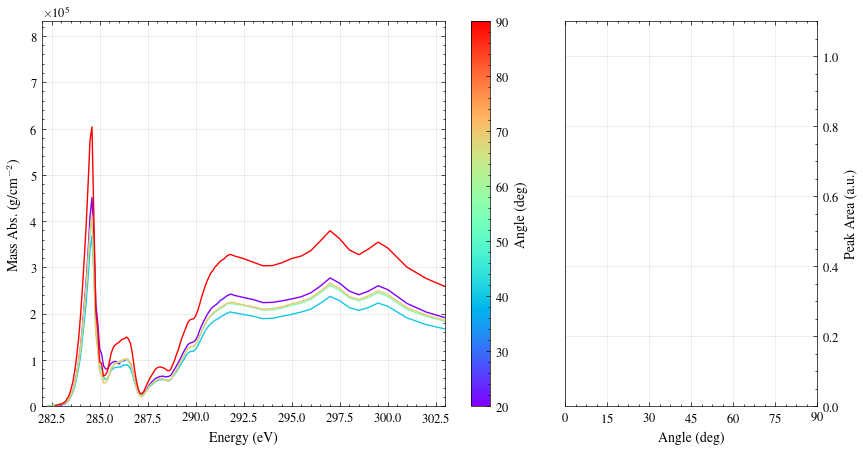

In [19]:
df_norm = normalize_by_group(
    df, normalization_mode="bare_atom"
)
fig, ax = plt.subplots(
    ncols=2,
    figsize=(10, 5),
    gridspec_kw={
        "width_ratios": [2, 1],
        "wspace": 0.05,
        },
)
df_norm.nexafs.plot(
    x="beamline_energy",
    y="mass_absorption_0",
    by="sample_theta",
    colorbar="Angle (deg)",
    cmap="rainbow",
    ax=ax[0],
)
ax[0].set_xlabel("Energy (eV)")
ax[0].set_ylabel("Mass Abs. (g/cm$^{-2}$)")
# scientific notation
ax[0].ticklabel_format(style="sci", axis="y", scilimits=(0,0))
ax[0].set_xlim(282, 303)

ax[1].set_xlabel("Angle (deg)")
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_ylabel("Peak Area (a.u.)")
ax[1].set_ylim(0, 1.1)
ax[1].set_xlim(0, 90)
ax[1].set_xticks(np.arange(0, 91, 15))


## Peak Fitting

There are three aspects to the peak fitting:

1. The absorption ionization step edge - this is a modified step edge that is modified from the bare atom absorption. It accounts for the ionization energy where electrons are photo-ionized into the continuum. We need to fit a energy location, and an energy width.
2. Peak location - this happens before we perform the fit and is used to determine the number of peaks and their reletive locations.
3. Multi-peak fit - this is the fit of the peaks. Here we fit the peaks + absorption edge to the data. Each peak is a lorentzian function consisiting of a resonant energy, energy width, amplitude, and shape factor.

### Function

- step edge

  $$
  edge(E, E_0, w) = G(E, E_0, w) * \begin{cases}
      P(E; a, b, c) & E < E_0 \\
      P(E; a', b', c') & E \geq E_0
  \end{cases}
  $$

- peak
  $$
  p(E, E_0, w, A, \gamma) = A(\gamma G(E, E_0, w) + (1 - \gamma)L(E, E_0, w))
  $$
  $$
  G(E, E_0, w) = \frac{2\sqrt{2\ln(2)}}{w\sqrt{2\pi}}e^{-\frac{2\ln(2)(E-E_0)^2}{w^2}}
  $$
  $$
  L(E, E_0, w) = \frac{1}{\pi}\frac{w/2}{(w/2)^2 + (E-E_0)^2}
  $$


In [224]:
from scipy.optimize import curve_fit
from scipy.signal import convolve
import numpy as np

df_first = df_norm.groupby("sample_theta").get_group(45)

bare_atom = df_first[
    ["beamline_energy", "bare_atom"]
]


pre_edge = bare_atom[bare_atom["beamline_energy"] < 284.2]
post_edge = bare_atom[bare_atom["beamline_energy"] >= 284.4]

pre_edge_fit = np.polyfit(pre_edge["beamline_energy"], pre_edge["bare_atom"], 3)
post_edge_fit = np.polyfit(post_edge["beamline_energy"], post_edge["bare_atom"], 3)

def gaussian(E, E_0, A, w):
    sigma = w / (2 * np.sqrt(2 * np.log(2)))
    A /= sigma * np.sqrt(2 * np.pi)
    return A * np.exp(-(E - E_0)**2 / (2 * sigma**2))

def lorentzian(E, E_0, w):
    return 1 / (np.pi * w * (1 + ((E - E_0) / w)**2))

def voigt(E, E_0, w, A, g):
    return A * (
        g * gaussian(E, E_0, 1, w) +
        (1 - g) * lorentzian(E, E_0, w)
    )


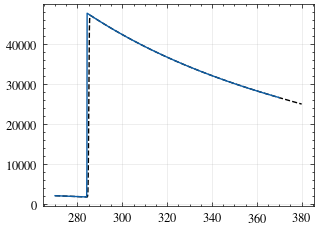

In [225]:
from functools import lru_cache

# Pre-allocate work buffers and kernel cache to avoid repeated allocation in step_edge
_step_edge_kernel_cache = {}

def _get_gaussian_kernel(w, dE):
    # Keyed by (w, dE)
    key = (float(w), float(dE))
    kernel = _step_edge_kernel_cache.get(key)
    if kernel is not None:
        return kernel
    kernel_width_points = int(np.round(6 * w / dE))
    if kernel_width_points % 2 == 0:
        kernel_width_points += 1
    kernel_E = np.linspace(-3 * w, 3 * w, kernel_width_points)
    k = gaussian(kernel_E, 0, 1, w)
    k /= np.sum(k)
    _step_edge_kernel_cache[key] = k
    return k

def step_edge(E, E_0, w):
    # Uses locally cached kernel and minimal allocation for efficiency.
    # "A" is currently unused, kept for future compatibility.
    global pre_edge_fit, post_edge_fit
    E = np.atleast_1d(E)
    n_points = E.shape[0]
    if n_points < 2:
        dE = 1.0
    else:
        dE = E[1] - E[0]

    # Padding by +/-3*sigma
    pad_width = int(np.ceil(3 * w / dE))
    # Use pre-allocated work buffers if n_points is modest
    E_left = E[0] - np.arange(pad_width, 0, -1) * dE
    E_right = E[-1] + np.arange(1, pad_width + 1) * dE
    E_extended = np.concatenate([E_left, E, E_right])

    # Use fast in-place computation for the piecewise polynomial
    y_extended = np.empty_like(E_extended, dtype=np.float64)
    mask = E_extended < E_0
    y_extended[mask] = np.polyval(pre_edge_fit, E_extended[mask])
    y_extended[~mask] = np.polyval(post_edge_fit, E_extended[~mask])

    # Get/calculate the gaussian kernel only once for each (w, dE)
    kernel = _get_gaussian_kernel(w, dE)

    # Convolve using 'same' mode (scipy.signal.convolve is already fast)
    convolved = convolve(y_extended, kernel, mode="same", method="auto")

    # Return only the region covering original E
    start = pad_width
    end = pad_width + n_points
    return convolved[start:end]

common_energy = np.linspace(270, 380, 1000)

plt.plot(
    common_energy,
    step_edge(
        common_energy,
        285, .5),
    label="Step Edge",
    color="k",
    ls="--",
)
plt.plot(
    df_first["beamline_energy"],
    df_first["bare_atom"],
)

In [237]:
from dataclasses import dataclass

def _scalar(x):
    return float(np.asarray(x).flat[0])

@dataclass
class Peak:
    e: float
    a: float
    w: float
    g: float

    @property
    def p0(self):
        return [_scalar(self.e), _scalar(self.w), _scalar(self.a), _scalar(self.g)]

    @p0.setter
    def p0(self, value):
        self.e = value[0]
        self.w = value[1]
        self.a = value[2]
        self.g = value[3]

    def model(self, E, *p):
        return voigt(E, *p)

    def __call__(self, E):
        return self.model(E, *self.p0)

    def __add__(self, other):
        return self(other.e) + other(self.e)

    @property
    def ub(self):
        return [self.e + .5, self.w + 2, 10*self.a, 1]

    @property
    def lb(self):
        return [self.e - .5, .1, 0, 0]

@dataclass
class StepEdge:
    e: float
    w: float

    @property
    def p0(self):
        return [_scalar(self.e), _scalar(self.w)]

    @p0.setter
    def p0(self, value):
        self.e = value[0]
        self.w = value[1]

    def model(self, E, *p):
        return step_edge(E, *p)

    def __call__(self, E):
        return self.model(E, *self.p0)

    @property
    def ub(self):
        return [310, 5]

    @property
    def lb(self):
        return [270, .1]

class PeakSet:
    def __init__(self, step_edge: StepEdge, peaks: list[Peak]):
        self.peaks = peaks
        self.step_edge = step_edge

    def model(self, E, *p):
        res = self.step_edge.model(E, *p[:2])
        for i, peak in enumerate(self.peaks):
            res += peak.model(E, *p[2 + 4 * i : 2 + 4 * (i + 1)])
        return res

    def __call__(self, E):
        return self.model(E, *self.p0)

    def _concat_property(self, prop):
        params = list(getattr(self.step_edge, prop))
        for p in self.peaks:
            params.extend(getattr(p, prop))
        return params

    @property
    def p0(self):
        """
        Returns a flat list of parameters in the order:
        [step_edge params..., all peaks' params...]
        suitable for passing into the model.
        """
        return self._concat_property("p0")

    @p0.setter
    def p0(self, value):
        self.step_edge.p0 = value[:2]
        for i, peak in enumerate(self.peaks):
            peak.p0 = value[2 + 4 * i : 2 + 4 * (i + 1)]

    @property
    def ub(self):
        return self._concat_property("ub")

    @property
    def lb(self):
        return self._concat_property("lb")

    def bounds(self):
        lb = np.array([float(x) for x in self.lb])
        ub = np.array([float(x) for x in self.ub])
        return (lb, ub)

    def bounds2(self):
        lb, ub = self.bounds()
        return list(zip(lb, ub))

    def _fit_indices(self, *components: str) -> list[int]:
        position = [0] + [2 + 4 * i for i in range(len(self.peaks))]
        width = [1] + [2 + 4 * i + 1 for i in range(len(self.peaks))]
        amplitude = [2 + 4 * i + 2 for i in range(len(self.peaks))]
        shape = [2 + 4 * i + 3 for i in range(len(self.peaks))]
        mapping = {
            "step_edge": [0, 1],
            "position": position,
            "width": width,
            "amplitude": amplitude,
            "shape": shape,
        }
        indices = []
        for name in components:
            if name not in mapping:
                raise ValueError(f"unknown component {name!r}; use one of {list(mapping)}")
            indices.extend(mapping[name])
        return sorted(set(indices))

    def fit_config(self, *components: str):
        """
        Return (x0_free, bounds2_free, expand) for fitting only the given components.
        components: any of 'step_edge', 'position', 'width', 'amplitude', 'shape'.
        Use: x0, bnds, expand = peakset.fit_config('amplitude', 'position')
             out = minimize(lambda p: obj(expand(p)), x0, bounds=bnds, ...)
             peakset.p0 = expand(out.x)
        """
        free = self._fit_indices(*components)
        full_p0 = np.array(self.p0, dtype=float)
        full_bounds = self.bounds2()
        x0_free = [full_p0[i] for i in free]
        bounds2_free = [full_bounds[i] for i in free]

        def expand(p_free):
            out = full_p0.copy()
            for j, i in enumerate(free):
                out[i] = p_free[j]
            return out.tolist()

        return x0_free, bounds2_free, expand

    def plot(self, E, ax=None):
        if ax is None:
            fig, ax = plt.subplots()
        step = self.step_edge(E)
        ax.plot(E, step, color="k", ls="--")
        for i, p in enumerate(self.peaks):
            ax.axvline(p.e, color=f"C{i}", ls="--")
            ax.plot(E, p(E) + step, color=f"C{i}")
        return ax

    def _order_peaks(self):
        return sorted(self.peaks, key=lambda p: p.e)

    def add_peak(self, peak: Peak):
        self.peaks.append(peak)
        self.peaks = self._order_peaks()
        return self

    def insert_between(self, loc: int):
        left = self.peaks[loc]
        right = self.peaks[loc + 1]
        new_peak = Peak(
            (left.e + right.e) / 2,
            left.a / 2,
            np.interp(
                (left.e + right.e) / 2,
                [left.e, right.e],
                [left.w, right.w],
            ),
            g=1,
        )
        self.peaks.insert(loc + 1, new_peak)
        self.peaks = self._order_peaks()
        return self


class MultiAnglePeakSet:
    def __init__(self, base_peakset: PeakSet, angles: list[float], amplitudes: np.ndarray | None = None):
        self.step_edge = StepEdge(base_peakset.step_edge.e, base_peakset.step_edge.w)
        self.peaks = [Peak(p.e, p.a, p.w, p.g) for p in base_peakset.peaks]
        self.angles = list(angles)
        self.n_peaks = len(self.peaks)
        self.n_angles = len(self.angles)
        if amplitudes is None:
            base_amp = np.array([p.a for p in self.peaks], dtype=float)
            self.amplitudes = np.tile(base_amp[None, :], (self.n_angles, 1))
        else:
            amp = np.asarray(amplitudes, dtype=float)
            if amp.shape != (self.n_angles, self.n_peaks):
                raise ValueError(f"amplitudes must have shape {(self.n_angles, self.n_peaks)}, got {amp.shape}")
            self.amplitudes = amp.copy()

    @property
    def _shared_len(self) -> int:
        return 2 + 3 * self.n_peaks

    def _shared_p0(self) -> list[float]:
        vals = [float(self.step_edge.e), float(self.step_edge.w)]
        for p in self.peaks:
            vals.extend([float(p.e), float(p.w), float(p.g)])
        return vals

    def _shared_lb(self) -> list[float]:
        vals = list(self.step_edge.lb)
        for p in self.peaks:
            vals.extend([p.lb[0], p.lb[1], p.lb[3]])
        return vals

    def _shared_ub(self) -> list[float]:
        vals = list(self.step_edge.ub)
        for p in self.peaks:
            vals.extend([p.ub[0], p.ub[1], p.ub[3]])
        return vals

    def _amp_lb(self) -> np.ndarray:
        return np.array([p.lb[2] for p in self.peaks], dtype=float)

    def _amp_ub(self) -> np.ndarray:
        return np.array([p.ub[2] for p in self.peaks], dtype=float)

    @property
    def p0(self) -> list[float]:
        shared = np.array(self._shared_p0(), dtype=float)
        amp = self.amplitudes.reshape(-1)
        return np.concatenate([shared, amp]).tolist()

    @p0.setter
    def p0(self, value):
        p = np.asarray(value, dtype=float)
        expected = self._shared_len + self.n_angles * self.n_peaks
        if p.size != expected:
            raise ValueError(f"parameter vector must have length {expected}, got {p.size}")
        self.step_edge.p0 = p[:2].tolist()
        for i, peak in enumerate(self.peaks):
            base = 2 + 3 * i
            peak.e = float(p[base])
            peak.w = float(p[base + 1])
            peak.g = float(p[base + 2])
        amp_start = self._shared_len
        self.amplitudes = p[amp_start:].reshape(self.n_angles, self.n_peaks).copy()

    def bounds2(self) -> list[tuple[float, float]]:
        shared_lb = np.array(self._shared_lb(), dtype=float)
        shared_ub = np.array(self._shared_ub(), dtype=float)
        amp_lb = np.tile(self._amp_lb()[None, :], (self.n_angles, 1)).reshape(-1)
        amp_ub = np.tile(self._amp_ub()[None, :], (self.n_angles, 1)).reshape(-1)
        lb = np.concatenate([shared_lb, amp_lb])
        ub = np.concatenate([shared_ub, amp_ub])
        return list(zip(lb.tolist(), ub.tolist()))

    def model_angle(self, E, p, angle_idx: int):
        p = np.asarray(p, dtype=float)
        e0 = float(p[0])
        w0 = float(p[1])
        step = step_edge(E, e0, w0)
        amp_start = self._shared_len + angle_idx * self.n_peaks
        out = np.array(step, dtype=float)
        for i in range(self.n_peaks):
            shared = 2 + 3 * i
            e = float(p[shared])
            w = float(p[shared + 1])
            g = float(p[shared + 2])
            a = float(p[amp_start + i])
            out += voigt(E, e, w, a, g)
        return out

    def as_peakset(self, angle_idx: int) -> PeakSet:
        if angle_idx < 0 or angle_idx >= self.n_angles:
            raise IndexError(f"angle_idx must be in [0, {self.n_angles - 1}]")
        peaks = []
        for i, p in enumerate(self.peaks):
            peaks.append(Peak(float(p.e), float(self.amplitudes[angle_idx, i]), float(p.w), float(p.g)))
        return PeakSet(StepEdge(float(self.step_edge.e), float(self.step_edge.w)), peaks)

    def _fit_indices(self, *components: str, angle_indices: list[int] | None = None) -> list[int]:
        position = [0] + [2 + 3 * i for i in range(self.n_peaks)]
        width = [1] + [2 + 3 * i + 1 for i in range(self.n_peaks)]
        shape = [2 + 3 * i + 2 for i in range(self.n_peaks)]
        if angle_indices is None:
            angle_indices = list(range(self.n_angles))
        amp_idx = []
        for a_idx in angle_indices:
            base = self._shared_len + a_idx * self.n_peaks
            amp_idx.extend([base + i for i in range(self.n_peaks)])
        mapping = {
            "step_edge": [0, 1],
            "position": position,
            "width": width,
            "shape": shape,
            "amplitude": amp_idx,
        }
        indices = []
        for name in components:
            if name not in mapping:
                raise ValueError(f"unknown component {name!r}; use one of {list(mapping)}")
            indices.extend(mapping[name])
        return sorted(set(indices))

    def fit_config(self, *components: str, angle_indices: list[int] | None = None):
        free = self._fit_indices(*components, angle_indices=angle_indices)
        full_p0 = np.array(self.p0, dtype=float)
        full_bounds = self.bounds2()
        x0_free = [full_p0[i] for i in free]
        bounds2_free = [full_bounds[i] for i in free]

        def expand(p_free):
            out = full_p0.copy()
            for j, i in enumerate(free):
                out[i] = p_free[j]
            return out.tolist()

        return x0_free, bounds2_free, expand

(280.0, 300.0)

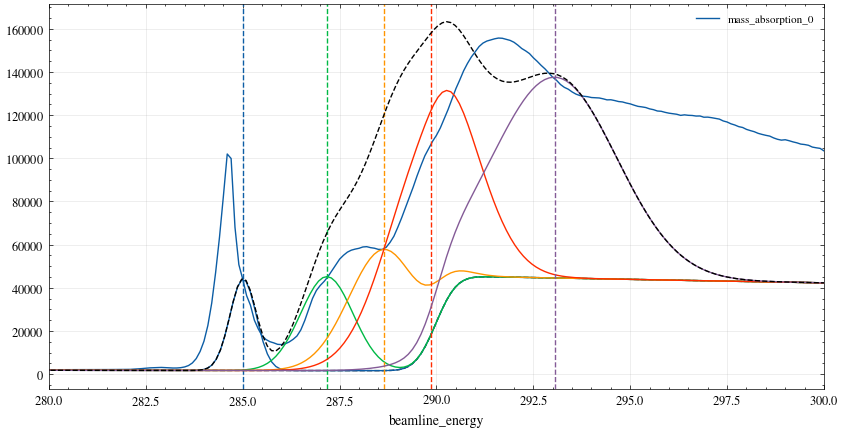

In [251]:
from scipy.signal import find_peaks

# Find peaks in the data from the first bare atom spectrum
peaks, _ = find_peaks(
    df_first["mass_absorption_0"],
    prominence=0.01,
    width=.5,
    rel_height=.3,
    )

peak_e = [285.01, 287.17, 288.65, 293.05, 289.86]

# Find the closest energies in the beamline_energy column
closest_energy = [
    df_first["beamline_energy"].iloc[(df_first["beamline_energy"] - e).abs().argmin()]
    for e in peak_e
]

peak_a = [
    df_first[df_first["beamline_energy"] == e]["mass_absorption_0"].iloc[0]
    for e in closest_energy
]


def build_peakset(peak_e, peak_a, step_energy, step_width):
    peakset = PeakSet(
        StepEdge(step_energy, step_width),
        [],
    )
    for i, (e, a) in enumerate(
            zip(peak_e, peak_a)
        ):
        if e > 320:
            continue
        if e > 284.2:
            width = np.interp(
                e,
                [284.2, 310],
                [.5, 10],
            )
            height = a - step_edge(e, step_energy, step_width)
            amplitude = height / voigt(e, e, width, 1, 1)
            peakset.add_peak(Peak(e, amplitude, width, 1))
    return peakset

peakset = build_peakset(peak_e, peak_a, 290, 1)


fig, ax = plt.subplots(figsize=(10, 5))
df_first.plot(x="beamline_energy", y="mass_absorption_0", ax=ax)
ax = peakset.plot(common_energy, ax=ax)
ax.plot(common_energy, peakset(common_energy), color="k", ls="--")
ax.set_xlim(280, 300)

In [239]:
energy_window = (283, 310)
angles = sorted(df_norm["sample_theta"].unique())

datasets = []
for theta in angles:
    g = df_norm.groupby("sample_theta").get_group(theta)
    mask = (g["beamline_energy"] > energy_window[0]) & (g["beamline_energy"] < energy_window[1])
    d = g[mask]
    x = d["beamline_energy"].to_numpy(dtype=float)
    y = d["mass_absorption_0"].to_numpy(dtype=float)
    err = np.maximum(np.abs(0.01 * y), 1e-12)
    datasets.append((float(theta), x, y, err))

multi_peakset = MultiAnglePeakSet(peakset, angles)

def obj(p):
    total = 0.0
    for i, (_, x, y, err) in enumerate(datasets):
        pred = multi_peakset.model_angle(x, p, i)
        resid = (pred - y) / err
        total += float(np.sum(resid**2))
    return total

In [240]:
from scipy.optimize import minimize

x0, bnds, expand = multi_peakset.fit_config(
    "amplitude", "position", "step_edge")
out = minimize(
    lambda p: obj(expand(p)),
    x0,
    method="SLSQP",
    bounds=bnds,
)
multi_peakset.p0 = expand(out.x)

x0, bnds, expand = multi_peakset.fit_config(
    "shape")
out = minimize(
    lambda p: obj(expand(p)),
    x0,
    method="SLSQP",
    bounds=bnds,
)
multi_peakset.p0 = expand(out.x)

x0, bnds, expand = multi_peakset.fit_config(
    "amplitude", "position", "width", "shape")
out = minimize(
    lambda p: obj(expand(p)),
    x0,
    method="SLSQP",
    bounds=bnds,
)

peakset = multi_peakset.as_peakset(0)

(283.0, 300.0)

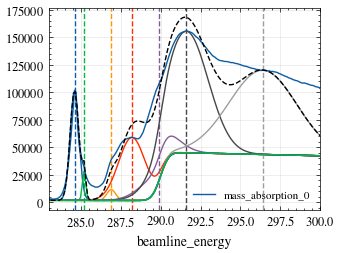

In [246]:
ax = peakset.plot(common_energy)
df_first.plot(x="beamline_energy", y="mass_absorption_0", ax=ax)
ax.plot(common_energy, peakset(common_energy), color="k", ls="--")
ax.set_xlim(283, 300)

Text(0.5, 1.0, 'Global multi-angle fit with shared edge/position/width/shape')

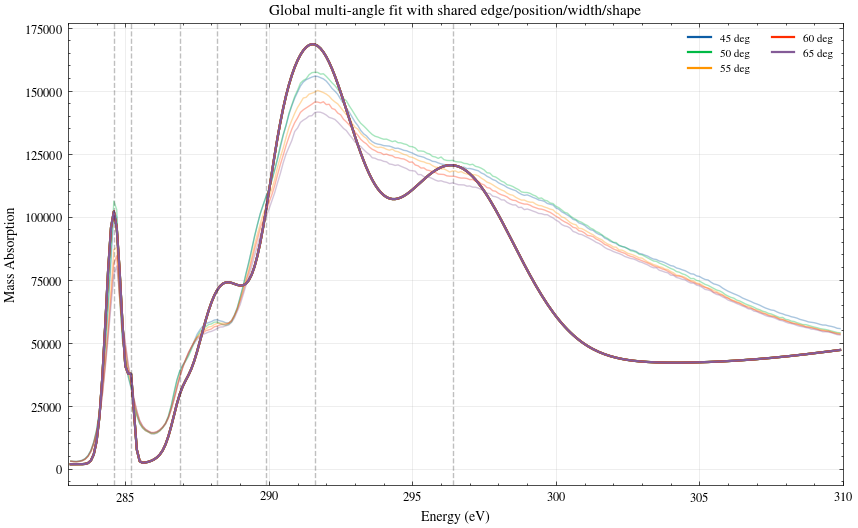

In [241]:
fig, ax = plt.subplots(figsize=(10, 6))
for i, (theta, x, y, _) in enumerate(datasets):
    c = f"C{i % 10}"
    ax.plot(x, y, color=c, alpha=0.35, lw=1)
    ax.plot(x, multi_peakset.model_angle(x, multi_peakset.p0, i), color=c, lw=1.6, label=f"{theta:g} deg")

for p in multi_peakset.peaks:
    ax.axvline(p.e, color="k", ls="--", alpha=0.25)

ax.set_xlim(*energy_window)
ax.set_xlabel("Energy (eV)")
ax.set_ylabel("Mass Absorption")
ax.legend(ncol=2, fontsize=8)
ax.set_title("Global multi-angle fit with shared edge/position/width/shape")